In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

time_steps = 200

data = pd.DataFrame({
    'time': range(time_steps),
    'traffic_volume': np.sin(np.linspace(0, 20, time_steps)) * 100 + np.random.randint(50, 100, time_steps)
})

data.to_csv('traffic_time_series.csv', index=False)

data.head()

,time,traffic_volume
0,0,88.000000
1,1,88.033341
2,2,83.965422
3,3,121.696008
4,4,96.126893


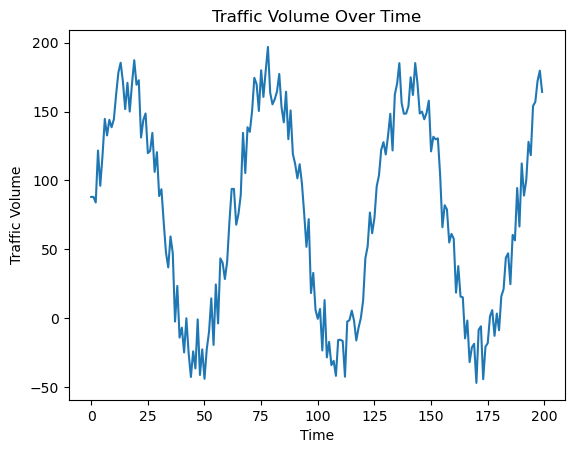

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(data['traffic_volume'])
plt.title("Traffic Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

In [3]:
data['prev_1'] = data['traffic_volume'].shift(1)
data['prev_2'] = data['traffic_volume'].shift(2)

data = data.dropna()

data.head()

,time,traffic_volume,prev_1,prev_2
2,2,83.965422,88.033341,88.000000
3,3,121.696008,83.965422,88.033341
4,4,96.126893,121.696008,83.965422
5,5,118.162900,96.126893,121.696008
6,6,144.712835,118.162900,96.126893


In [4]:
X = data[['prev_1', 'prev_2']]
y = data['traffic_volume']

In [5]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [6]:
predictions = model.predict(X)

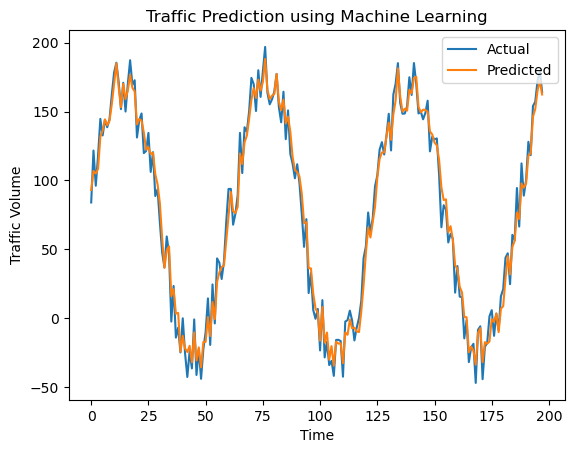

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(data['traffic_volume'].values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Traffic Prediction using Machine Learning")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

In [8]:
data['predicted'] = predictions
data.to_csv('final_predictions.csv', index=False)